<a href="https://colab.research.google.com/github/anuragpatil811/Machine-Learning/blob/main/Superstore_Profit_Prediction_LinReg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd


In [2]:
df = pd.read_csv('/content/SampleSuperstore.csv')
df.head(2)

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.96,2,0.0,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.94,3,0.0,219.5820


In [3]:
df.drop(columns=['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Category', 'Sub-Category'], inplace=True)

In [4]:
df.head()

,Sales,Quantity,Discount,Profit
0,261.9600,2,0.00,41.9136
1,731.9400,3,0.00,219.5820
2,14.6200,2,0.00,6.8714
3,957.5775,5,0.45,-383.0310
4,22.3680,2,0.20,2.5164


<Axes: ylabel='Sales'>

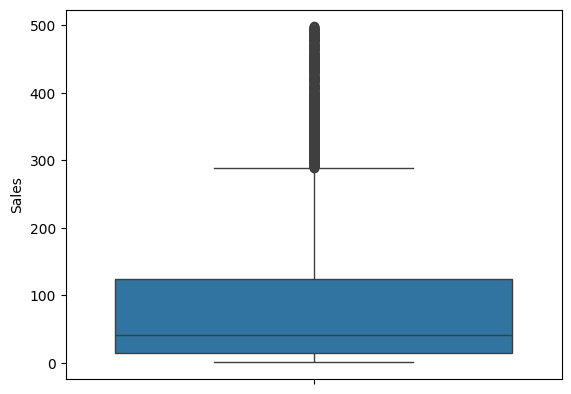

In [14]:
import seaborn as sns
sns.boxplot(data=df, y='Sales')

In [8]:
df["Sales"].describe()

,Sales
count,9994.000000
mean,229.858001
std,623.245101
min,0.444000
25%,17.280000
50%,54.490000
75%,209.940000
max,22638.480000


In [23]:
q1 = 17.28
q3 = 209.94

In [24]:
IQR = q3 - q1

In [25]:
ub = q3 + 1.5*IQR
lb = q1 - 1.5*IQR

In [26]:
df = df[(df["Sales"]>lb)&(df["Sales"]<ub)]

<Axes: ylabel='Sales'>

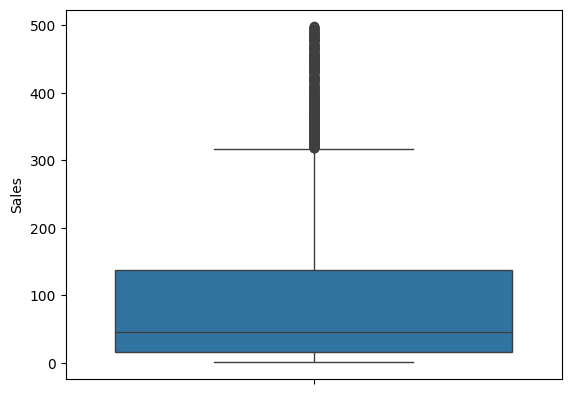

In [27]:
sns.boxplot(data=df, y="Sales")

In [15]:
df.isnull().sum()

,0
Sales,0
Quantity,0
Discount,0
Profit,0


In [16]:
df.duplicated().sum()

np.int64(2160)

In [17]:
df.drop_duplicates(inplace=True)

In [18]:
df["Quantity"].describe()

,Quantity
count,6667.000000
mean,3.759712
std,2.267680
min,1.000000
25%,2.000000
50%,3.000000
75%,5.000000
max,14.000000


In [19]:
q1 = 2
q3 = 5
IQR = q3 - q1

In [20]:
ub = q3 + 1.5*IQR
lb = q1 - 1.5*IQR

In [21]:
df = df[(df["Quantity"]>lb)&(df["Quantity"]<ub)]

<Axes: ylabel='Quantity'>

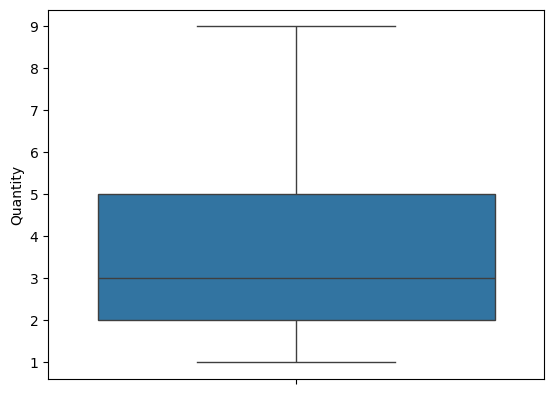

In [22]:
sns.boxplot(data=df, y="Quantity")

In [28]:
df["Discount"].describe()

,Discount
count,6549.000000
mean,0.177232
std,0.224579
min,0.000000
25%,0.000000
50%,0.200000
75%,0.200000
max,0.800000


In [29]:
q1 = 0.0
q3 = 0.2
IQR = q3 - q1

In [30]:
ub = q3 + 1.5*IQR
lb = q1 - 1.5*IQR

In [31]:
df = df[(df["Discount"]>lb)&(df["Discount"]<ub)]

<Axes: ylabel='Discount'>

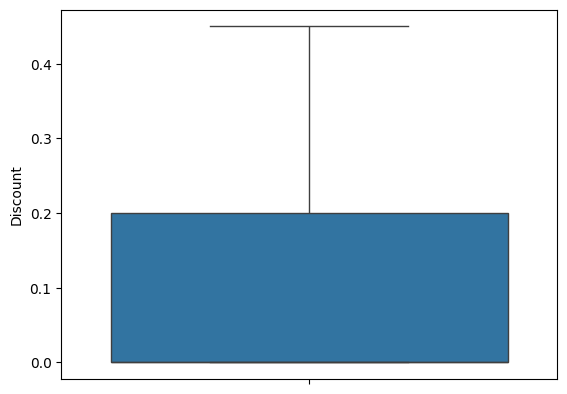

In [32]:
sns.boxplot(data=df, y="Discount")

In [34]:
x = df.drop("Profit", axis=1)
y = df["Profit"]

In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [36]:
from sklearn.linear_model import LinearRegression

In [37]:
model = LinearRegression()

In [38]:
model.fit(X_train, y_train)

LinearRegression()

In [39]:
y_predict = model.predict(X_test)

In [40]:
y_predict

array([-9.38540264, -0.99736338, 24.89181819, ...,  7.83327324,
       22.20883889, 58.20498274])

In [41]:
model.score(X_train, y_train)

0.34989720879983655

In [42]:
model.score(X_test, y_test)

0.3279228326493272